# Goal of this project



### Background (collected data)
1. Raw video
2. Keypoints tracking by SLEAP (.h and .slp)
3. ephys data (4-shank Neuropixels)

### What this script for:
1. Extract head centroid from the sleap inference output
2. Smooth the trajectory (remove jitter)
3. Interpolate missing frames (if any)
4. Calculate relevant behavioral metrics (e.g., speed, acceleration, distance traveled)
5. Export the frame-to-frame data

### prerequisite
Install "movement" package
see https://movement.neuroinformatics.dev/latest/user_guide/installation.html


In [52]:
# Import necessary packages

import movement
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, interpolate_over_time, rolling_filter
from movement.kinematics import compute_velocity
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Successfully imported packages, happy coding!")

Successfully imported packages, happy coding!


In [3]:
# Loading sleap inference data (.h5 / .slp)

## Change to your own project path
project_root_yjl = r"/Users/jialin/Documents/PhD_CodeBase/course-animals-in-motion/github_collaboration/Prototype-for-integrating-movement-SpikeInterface-and-pynapple-OSSS2026-/"
project_root_evan = r"C:/Users/moffi/Documents/UCL/Sainsbury Wellcome Centre/OSSS/Hackathon data"
project_root = ""
#

slp_file_name = "T1_1D_04032026_inference.slp"
h5_file_name = "T1_1D_04032026.h5"

## choose your project root
file_dir = Path(project_root_yjl)
file_name = h5_file_name
file_path = Path(file_dir)/"data"/"SLEAP_data(behavior)"/file_name

## check file exists or not
if file_path.exists():
    print(f"loading: {file_name}")
else:
    raise FileNotFoundError(f"File not found: {file_path}")

# loading single filedata
ds=load_dataset(file_path, fps=25)

loading: T1_1D_04032026.h5


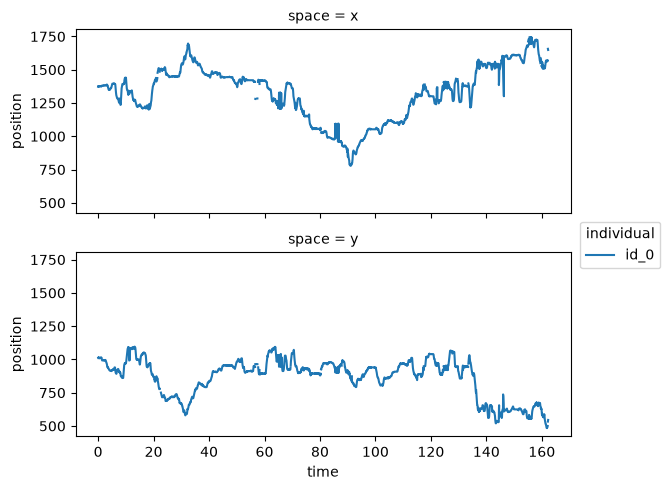

In [ ]:
ds_headcap = ds.sel(keypoint=["headcap"])
#visualise headcap position across space
ds_headcap.plot.line(x="time", row="space", aspect=2, size=2.5)

50% confidence: 0.9201700687408447
75% confidence: 0.9476786702871323


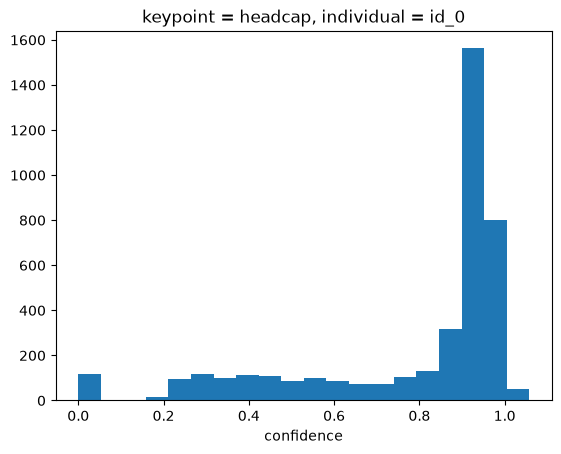

In [24]:
#Inspect outliers
ds_headcap.confidence.squeeze().plot.hist(bins=20)

q1, q2 = np.nanpercentile(ds_headcap.confidence.squeeze(), [50, 75])

print(f"50% confidence: {q1}")
print(f"75% confidence: {q2}")

Missing points (marked as NaN) in input:

keypoint               headcap
individual                    
id_0        1728/4135 (41.79%)
Missing points (marked as NaN) in output:

keypoint              headcap
individual                   
id_0        810/4135 (19.59%)
Missing points (marked as NaN) in input:

keypoint              headcap
individual                   
id_0        810/4135 (19.59%)
Missing points (marked as NaN) in output:

keypoint              headcap
individual                   
id_0        768/4135 (18.57%)


Text(0.5, 0.98, 'Headcap position across space: original, filtered, and interpolated')

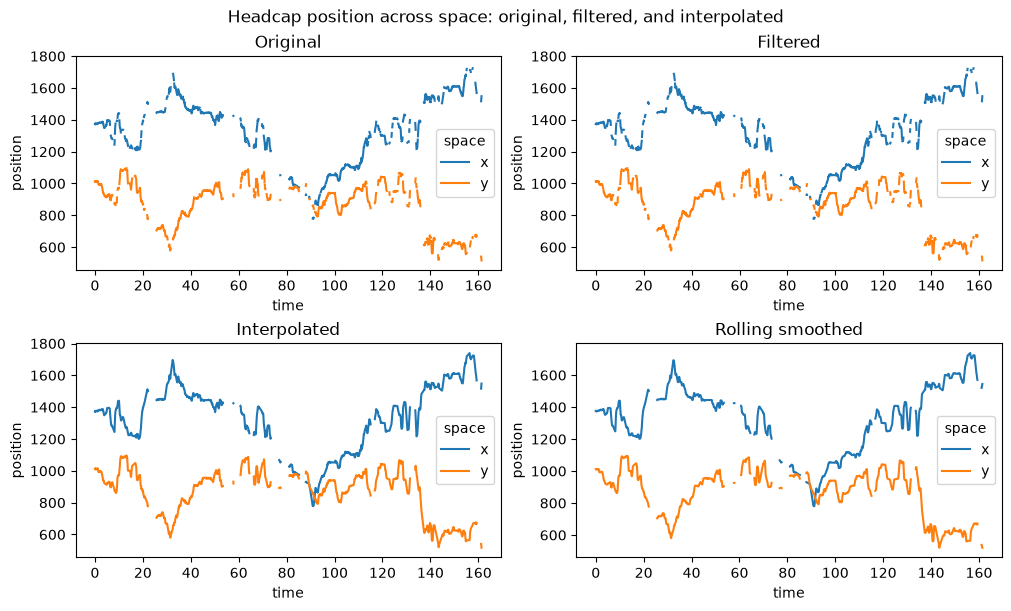

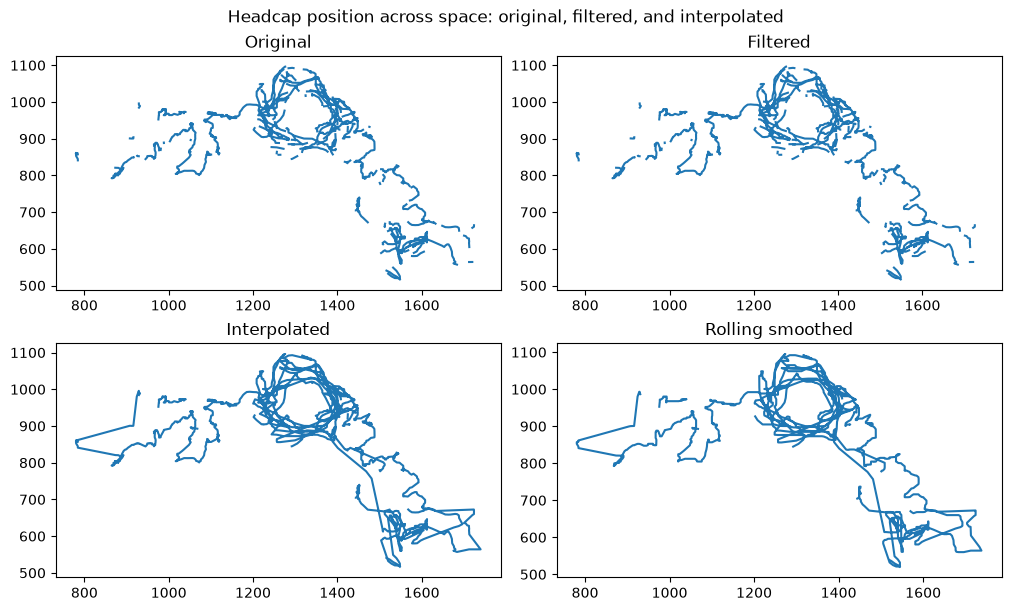

In [67]:
#Filter outliers, interpolate, and rolling smooth

# since the 75% confidence is around 0.9, why we select 0.9 or 0.8 as the threshold for filtering out low confidence data points. 

ds_headcap_pos = ds_headcap.position.copy()

ds_headcap_rm_LowConf = filter_by_confidence(
    ds_headcap_pos, ds_headcap.confidence, threshold=0.75, print_report=False)

#Interpolate filtered data
ds_headcap_interpolated = interpolate_over_time(
    ds_headcap_rm_LowConf,max_gap=35,print_report=True)

window=int(0.3*ds.fps)
ds_headcap_rolling = rolling_filter(
    ds_headcap_interpolated, window=window, min_periods=2, statistic="median", print_report=True
)

# timeseries plot of headcap position (x,y)
fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(10, 6),constrained_layout=True)
ds_headcap_pos.squeeze().plot.line(x="time", hue="space",ax = ax[0,0])
ax[0,0].set_title("Original")
ds_headcap_rm_LowConf.squeeze().plot.line(x="time", hue="space",ax = ax[0,1])
ax[0,1].set_title("Filtered")
ds_headcap_interpolated.squeeze().plot.line(x="time", hue="space",ax = ax[1,0])
ax[1,0].set_title("Interpolated")
ds_headcap_rolling.squeeze().plot.line(x="time", hue="space",ax = ax[1,1])
ax[1,1].set_title("Rolling smoothed")
fig.suptitle("Headcap position across space: original, filtered, and interpolated")


# visualize the headcap position

fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(10, 6),constrained_layout=True)
ax[0,0].plot(ds_headcap_pos.squeeze().sel(space="x"), ds_headcap_pos.squeeze().sel(space="y"), label="Original", alpha=1,)
ax[0,0].set_title("Original")

ax[0,1].plot(ds_headcap_rm_LowConf.squeeze().sel(space="x"), ds_headcap_rm_LowConf.squeeze().sel(space="y"), label="Filtered", alpha=1,)
ax[0,1].set_title("Filtered")
ax[0,1].set_xlim()
ax[0,1].set_ylim()

ax[1,0].plot(ds_headcap_interpolated.squeeze().sel(space="x"), ds_headcap_interpolated.squeeze().sel(space="y"), label="Interpolated", alpha=1,)
ax[1,0].set_title("Interpolated")
ax[1,0].set_xlim()
ax[1,0].set_ylim()

ax[1,1].plot(ds_headcap_rolling.squeeze().sel(space="x"), ds_headcap_rolling.squeeze().sel(space="y"), label="Rolling smoothed", alpha=1,)
ax[1,1].set_title("Rolling smoothed")
ax[1,1].set_xlim()
ax[1,1].set_ylim()

fig.suptitle("Headcap position across space: original, filtered, and interpolated")



In [68]:
#Generate pipeline log
print(ds_headcap.position.log)

[
  {
    "operation": "filter_by_confidence",
    "datetime": "2026-08-21 13:54:28.790295",
    "confidence": "<xarray.DataArray 'confidence' (time: 4135, keypoint: 1, individual: 1)> Size: 17kB\n0.9351 0.9452 0.9775 0.9764 0.952 0.9495 0.9492 ... nan nan nan nan nan nan nan\nCoordinates:\n  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4\n  * keypoint    (keypoint) <U9 36B 'headcap'\n  * individual  (individual) <U4 16B 'id_0'",
    "threshold": "0.8",
    "print_report": "True"
  },
  {
    "operation": "interpolate_over_time",
    "datetime": "2026-08-21 13:54:44.734506",
    "method": "'linear'",
    "max_gap": "40",
    "print_report": "True"
  },
  {
    "operation": "filter_by_confidence",
    "datetime": "2026-08-21 14:33:23.284089",
    "confidence": "<xarray.DataArray 'confidence' (time: 4135, keypoint: 1, individual: 1)> Size: 17kB\n0.9351 0.9452 0.9775 0.9764 0.952 0.9495 0.9492 ... nan nan nan nan nan nan nan\nCoordinates:\n  * time        (time